In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# kNN Regressor implementation - for binary classification

class kNNRegression:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict_one(self, x):
        distances = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
    
        knn_indicies = [np.argsort(distances)[:self.k]]

        knn_classes = [self.y_train[i] for i in knn_indicies]

        majority_avg = np.floor(np.average(knn_classes) + 0.5)
        return majority_avg

    def predict(self, X):
        y_pred = [self.predict_one(x) for x in X]
        return np.array(y_pred)

In [8]:
X_train = np.array([
    [1,2],
    [2,3],
    [3,3],
    [6,5],
    [7,7]
])

y_train = np.array([0,0,0,1,1])

X_test = np.array([
    [2,2],
    [6,6]
])

model = kNNRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

[0. 1.]


<Axes: xlabel='x1', ylabel='x2'>

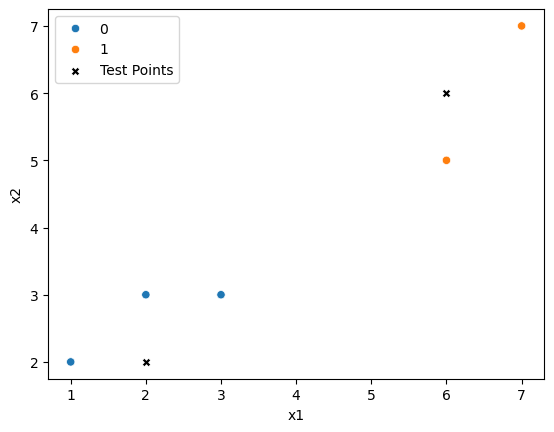

In [9]:
# Visualize 
X_train_df = pd.DataFrame(X_train, columns=["x1","x2"])
X_train_df["label"] = y_train

sns.scatterplot(
    X_train_df, 
    x="x1",
    y="x2",
    hue="label"
)

X_test_df = pd.DataFrame(X_test, columns=["x1","x2"])

sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="Test Points"
)

In [10]:
# more example
X_train = np.array([
    [1], 
    [2], 
    [3], 
    [4], 
    [5]
])
y_train = np.array([2, 4, 6, 8, 10])

X_test = np.array([
    [1.5], 
    [3.5], 
    [6]
])

y_test = np.array([
    [3],
    [7],
    [12]
])

model = kNNRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

[4. 6. 8.]


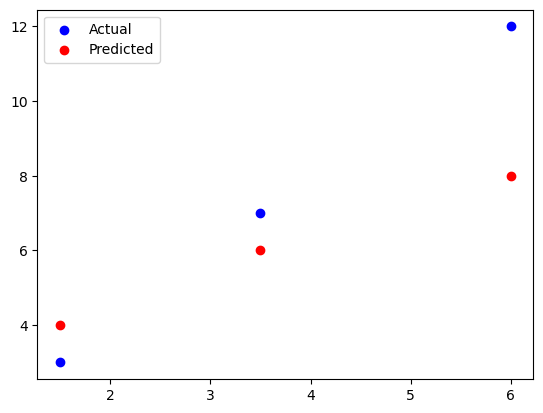

In [11]:
X_train_df = pd.DataFrame(X_train, columns=["x1"])
X_train_df["label"] = y_train

plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.scatter(X_test, y_pred, color="red", label="Predicted")
plt.legend()